In [238]:
import numpy as np
import datetime as dt
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

[*********************100%***********************]  1 of 1 completed


Original Data {'ADF Statistic ': -2.938320448949314, 'p-value ': 0.041069885165697456}
Resampled Data {'ADF Statistic ': -2.780540341269985, 'p-value ': 0.061107655217894005}


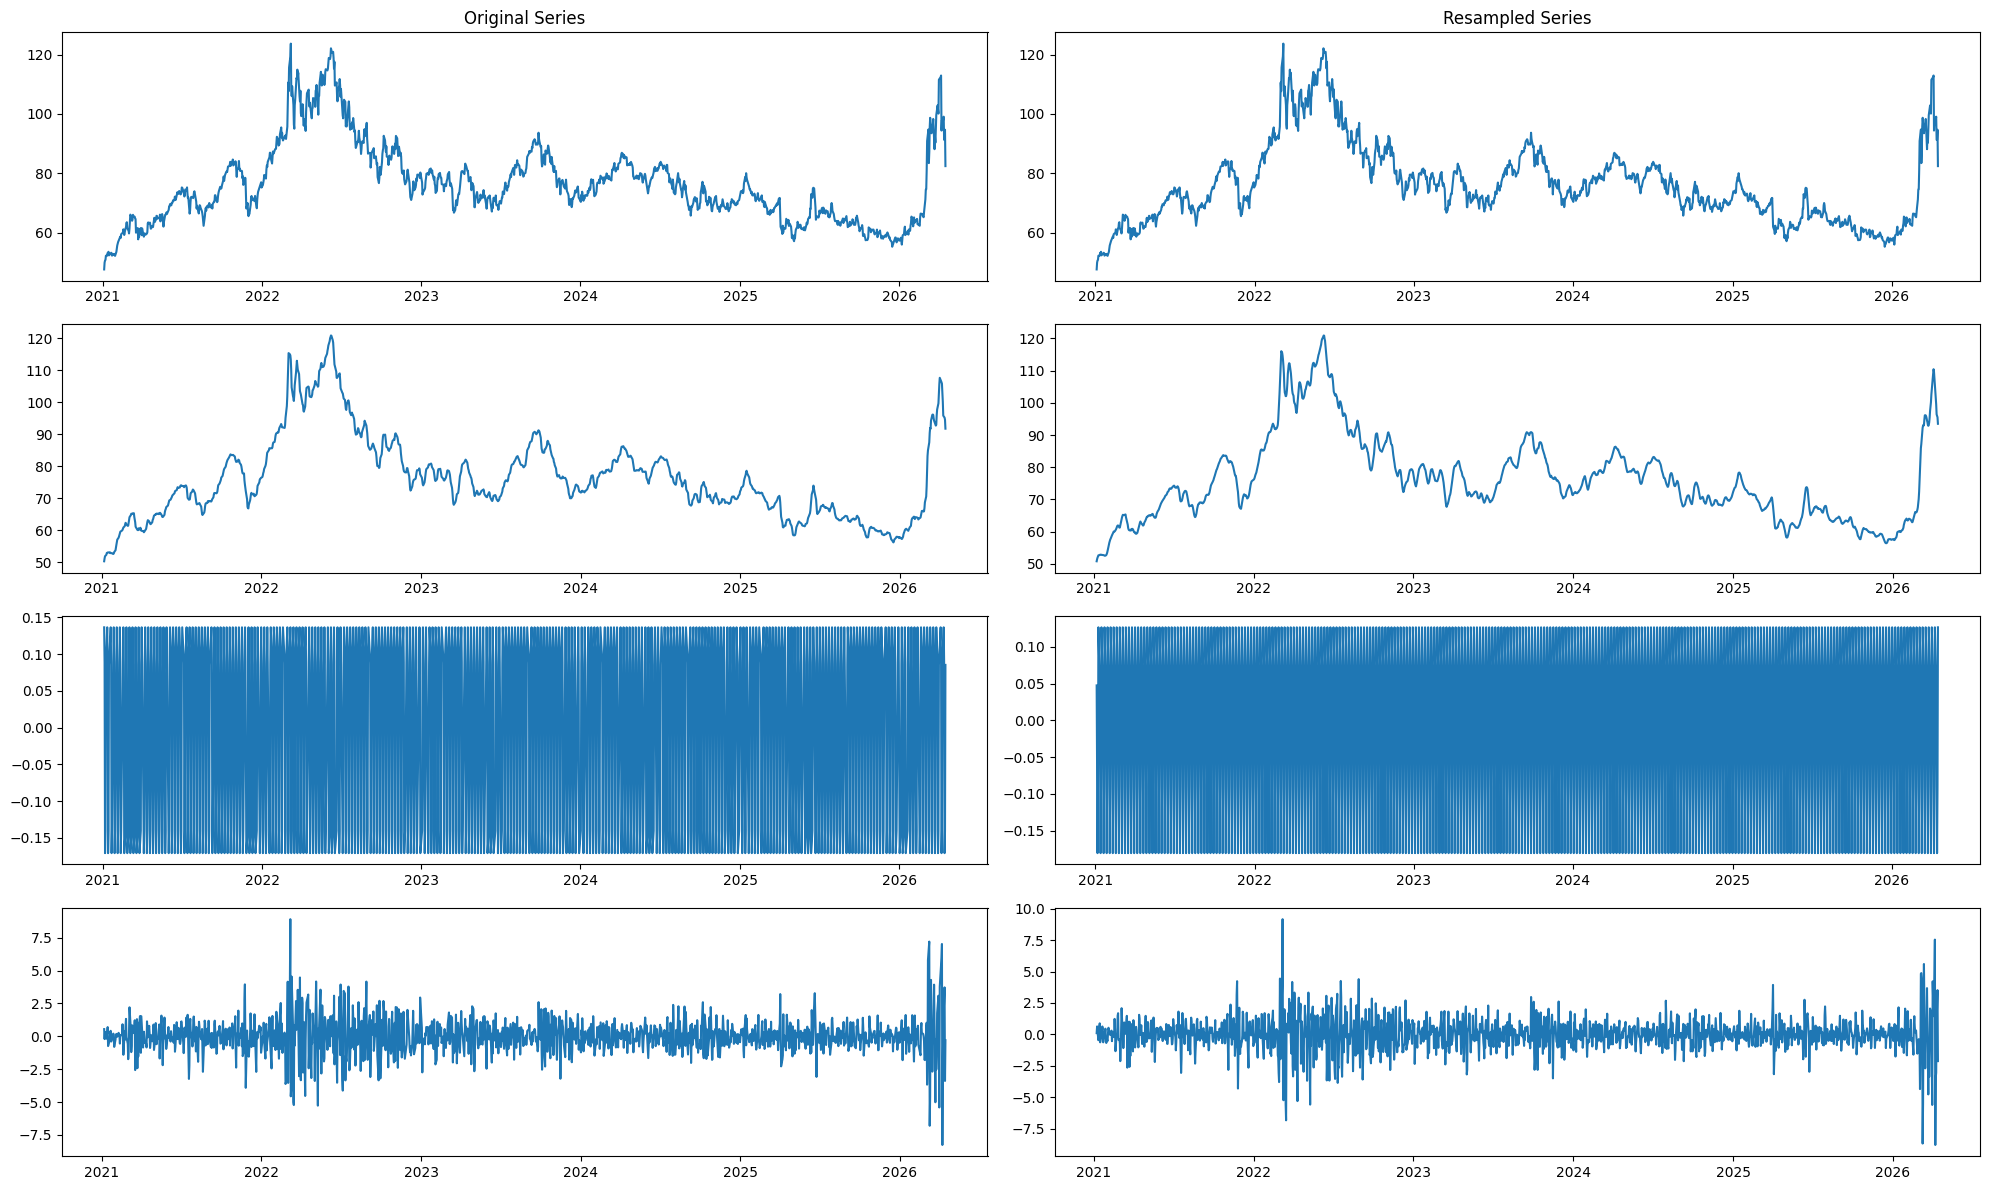

In [239]:
start = dt.date(2021,1,1)
end = dt.date(2025,1,1)

# Fetch WTI Crude Oil futures data
crude_oil_ticker = "CL=F"
oil = yf.download(crude_oil_ticker,start=start, interval="1d",auto_adjust=False,multi_level_index=False)['Adj Close']
oil = oil.rename("Close")

# Prepare the 'Close' price data for analysis
oil.index = pd.to_datetime(oil.index)
oil_resampled = oil.resample('D').mean().interpolate(method='linear')

def check_stationarity(series):
    result = adfuller(series)
    return{'ADF Statistic ': float(result[0]),
     'p-value ': float(result[1]),}

print("Original Data",check_stationarity(oil))
print("Resampled Data",check_stationarity(oil_resampled))

from statsmodels.tsa.seasonal import seasonal_decompose
decomposition_orig = seasonal_decompose(oil,model='additive',period=5)

decomposition_resampled = seasonal_decompose(oil_resampled,model='additive',period=7)



# --- ORIGINAL ---
trend_o = decomposition_orig.trend
seasonal_o = decomposition_orig.seasonal
residual_o = decomposition_orig.resid

# --- RESAMPLED ---
trend_r = decomposition_resampled.trend
seasonal_r = decomposition_resampled.seasonal
residual_r = decomposition_resampled.resid

plt.figure(figsize=(20,12))

# ===== ORIGINAL =====
plt.subplot(421)
plt.plot(oil, label='Original Data')
plt.title("Original Series")

plt.subplot(422)
plt.plot(oil_resampled, label='Resampled Data')
plt.title("Resampled Series")

plt.subplot(423)
plt.plot(trend_o, label='Trend (Original)')

plt.subplot(424)
plt.plot(trend_r, label='Trend (Resampled)')

plt.subplot(425)
plt.plot(seasonal_o, label='Seasonal (Original)')

plt.subplot(426)
plt.plot(seasonal_r, label='Seasonal (Resampled)')

plt.subplot(427)
plt.plot(residual_o, label='Residual (Original)')

plt.subplot(428)
plt.plot(residual_r, label='Residual (Resampled)')

plt.tight_layout()
plt.show()

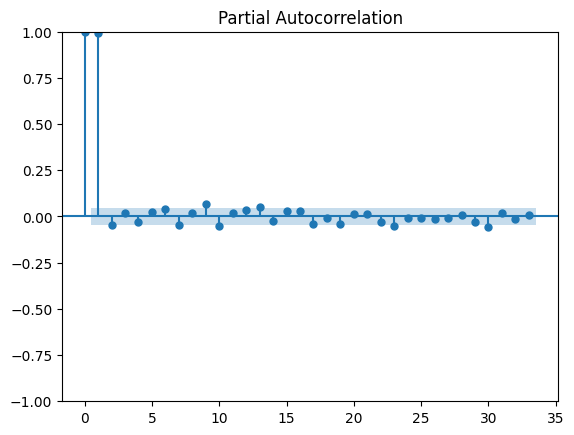

In [240]:
# Dropping NaN values in residuals
residual.dropna(inplace=True)

# Checking stationarity of residuals
check_stationarity(residual)

from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(oil_resampled)
plt.show()

In [241]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(residual, order=(1,0,0))
results = model.fit()

print(results.summary())

pred = results.predict(start=residual.index[0], end=residual.index[-1])

errors = residual - pred

                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                  248
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -467.632
Date:                Fri, 17 Apr 2026   AIC                            941.264
Time:                        19:17:09   BIC                            951.804
Sample:                             0   HQIC                           945.507
                                - 248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0038      0.115     -0.033      0.974      -0.230       0.222
ar.L1       6.179e-05      0.027      0.002      0.998      -0.053       0.053
sigma2         2.5430      0.107     23.662      0.0

In [242]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,r2_score

mae = mean_absolute_error(residual, pred)

mse = mean_squared_error(residual, pred)

rmse = np.sqrt(mse)

mape = mean_absolute_percentage_error(residual, pred)

r2 = r2_score(residual, pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("MAPE:",mape)
print("R2:",r2)

MAE: 0.9994886472995071
MSE: 2.543006204933126
RMSE: 1.5946805965249362
MAPE: 0.9998490122292236
R2: 3.2600471211452486e-09


# ResiDual Analysis


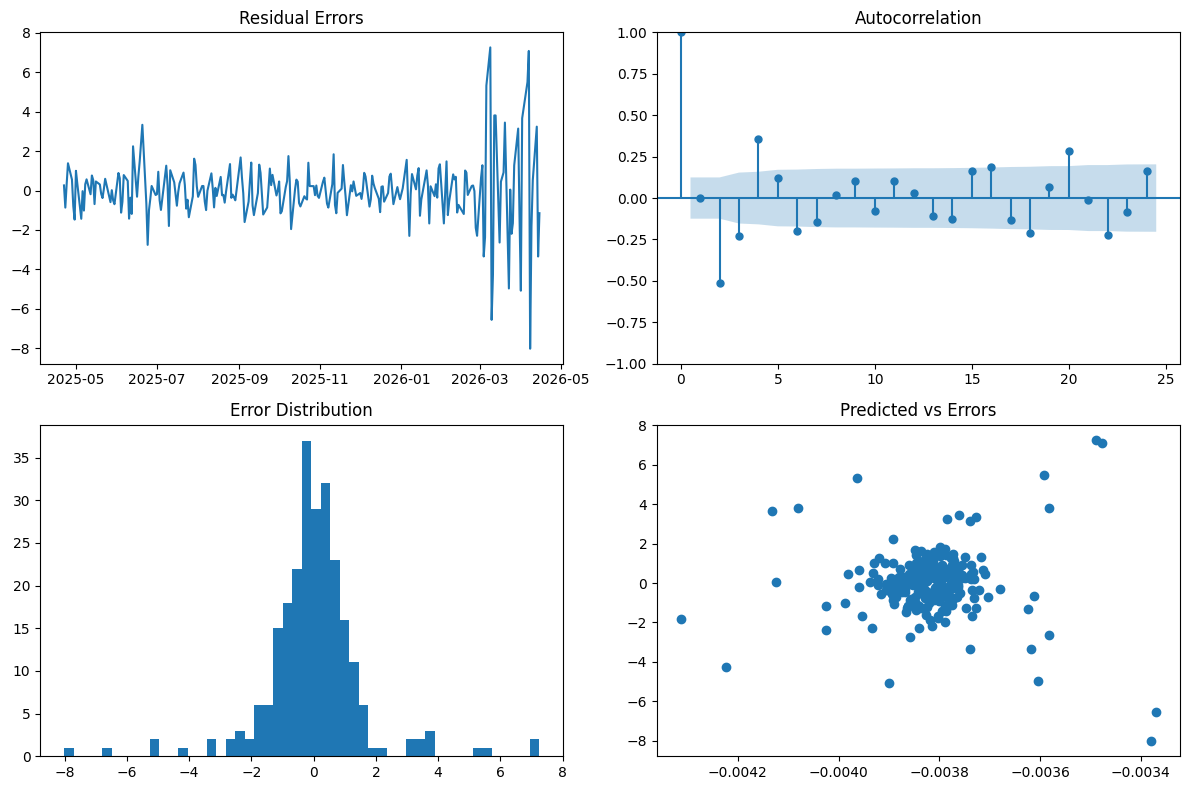

In [243]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Residual time series
axes[0, 0].plot(errors)
axes[0, 0].set_title("Residual Errors")

# 2. ACF
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(errors, ax=axes[0, 1])

# 3. Histogram
axes[1, 0].hist(errors, bins=50)
axes[1, 0].set_title("Error Distribution")

# 4. Predicted vs Errors
axes[1, 1].scatter(pred, errors)
axes[1, 1].set_title("Predicted vs Errors")

plt.tight_layout()
plt.show()

In [244]:
results_df = pd.DataFrame({
    "Actual": residual,
    "Predicted": pred,
    "Error": errors
})

In [245]:
results_df

,Actual,Predicted,Error
Date,,,
2025-04-22 00:00:00-04:00,0.254224,-0.003818,0.258041
2025-04-23 00:00:00-04:00,-0.869933,-0.003802,-0.866131
2025-04-24 00:00:00-04:00,0.313907,-0.003871,0.317779
2025-04-25 00:00:00-04:00,1.375860,-0.003798,1.379658
2025-04-28 00:00:00-04:00,0.549941,-0.003732,0.553673
...,...,...,...
2026-04-09 00:00:00-04:00,-1.840139,-0.004313,-1.835826
2026-04-10 00:00:00-04:00,0.525940,-0.003931,0.529871
2026-04-13 00:00:00-04:00,3.232227,-0.003785,3.236012


# Model Improvement

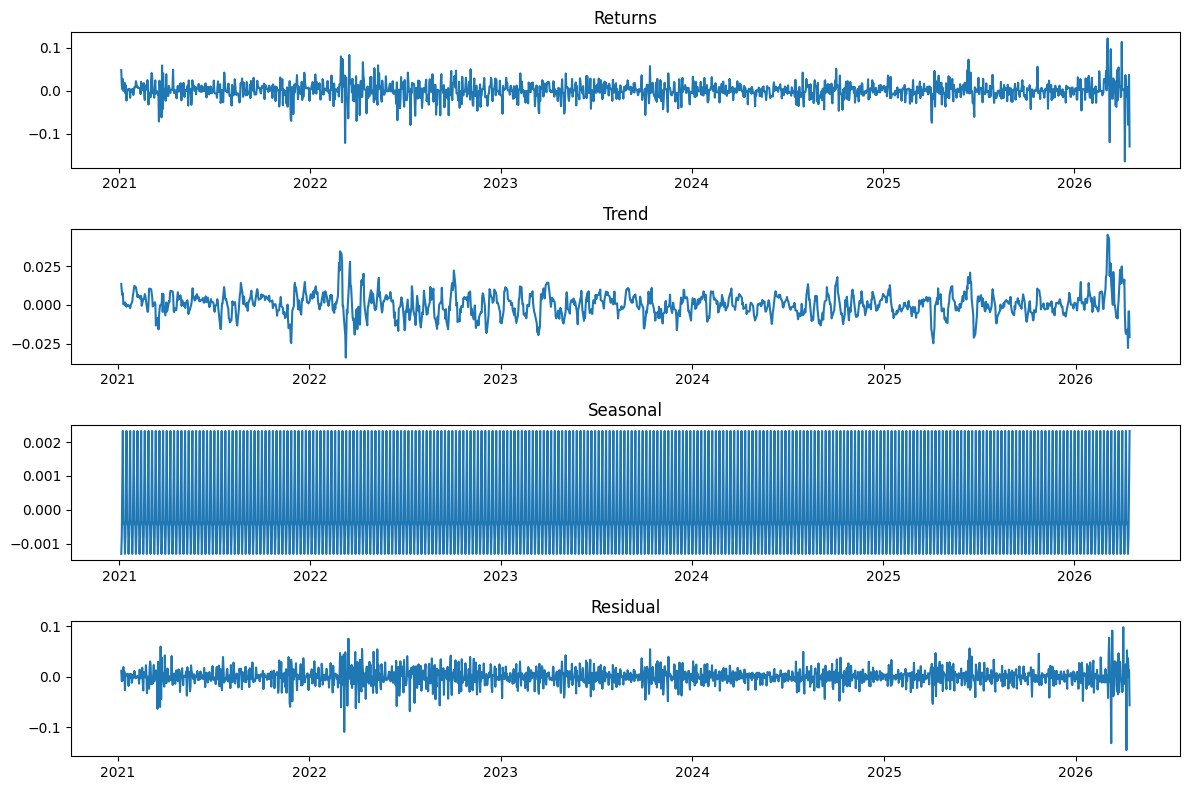

In [249]:
returns = oil_resampled.pct_change().dropna()
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_returns = seasonal_decompose(returns,model='additive',period=7)

# 3. Extract components
trend_r = decomposition_returns.trend
seasonal_r = decomposition_returns.seasonal
residual_r = decomposition_returns.resid

# 4. Drop NaN from residual
residual_r = residual_r.dropna()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.subplot(411)
plt.plot(returns)
plt.title("Returns")

plt.subplot(412)
plt.plot(trend_r)
plt.title("Trend")

plt.subplot(413)
plt.plot(seasonal_r)
plt.title("Seasonal")

plt.subplot(414)
plt.plot(residual_r)
plt.title("Residual")

plt.tight_layout()
plt.show()